# Split-Drift — a quantitative teardown
### Post-effective-date event study · matched baseline · HAC inference · survivorship caveat

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Post--effective_drift%3F: Absent](https://img.shields.io/badge/Post--effective_drift%3F-Absent-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim carrying its standard error.*  We test whether stock splits predict above-average forward returns at 1/3/6/12-month horizons, vs a within-stock matched-period baseline, on 30 large-cap US stocks 2000–2025.

> ⚠️ **Not investment advice.**  Real data: Yahoo Finance splits + daily closes, as-of 2026-06-14.  Event fingerprint `4b63fefd052e`.  Effective dates only — NOT announcement dates (see caveat).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from split_drift import data, strategy as st

# Frozen headline numbers (mirror of docs/results.md) — used when real cache is absent.
R = dict(
    n_events=41, n_tickers=22, n_base=205,
    sp_1m=-1.49,  sp_1m_t=-0.92,  sp_1m_win=43.9,
    sp_3m=0.4,  sp_3m_t=0.15,  sp_3m_win=53.7,
    sp_6m=-0.67,  sp_6m_t=-0.14,  sp_6m_win=58.5,
    sp_12m=5.14, sp_12m_t=0.99, sp_12m_win=62.5,
    bs_1m=2.06,  bs_1m_t=2.59,
    bs_3m=5.67,  bs_3m_t=4.68,
    bs_6m=11.74,  bs_6m_t=5.66,
    bs_12m=28.71, bs_12m_t=7.26,
    diff_1m=-3.55,  diff_1m_t=-2.2,
    diff_3m=-5.27,  diff_3m_t=-2.0,
    diff_6m=-12.42,  diff_6m_t=-2.5,
    diff_12m=-23.56, diff_12m_t=-4.56,
)

def _have_cache():
    # Check for at least one cached split file and one price file
    import glob
    sp_files = glob.glob(os.path.join(data.DEFAULT_CACHE, "splits_142_*.parquet"))
    pr_files = glob.glob(os.path.join(data.DEFAULT_CACHE, "prices_142_*_1d.parquet"))
    return len(sp_files) > 5 and len(pr_files) > 5

HAVE_REAL = _have_cache()

if HAVE_REAL:
    events, prices = data.fetch_splits_panel(fetch=False)
    baseline = st.build_baseline_events(events, prices, n_control_per_event=5, seed=142)
else:
    events, prices, baseline = None, None, None

print(f"real data cache present: {HAVE_REAL}")
if HAVE_REAL:
    print(f"  {len(events)} split events, {len(baseline)} baseline events")

from quantlab import analytics, stats


real data cache present: True
  41 split events, 205 baseline events


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Post-effective 12m mean **+5.1%**, HAC *t* = **+0.99**; every horizon |*t*| < 2.  vs matched baseline: **-23.6%** underperformance (*t* = -4.56). |
| **Tradability** | `MIRAGE` | ~2 events/yr in 30-stock basket; thin n, no significant gross edge, below-baseline returns. |
| **Post-effective drift?** | `ABSENT` | Split stocks underperform same-basket non-split periods: -3.5% (1m), -5.3% (3m), -12.4% (6m), -23.6% (12m). |

> 💡 The anomaly Ikenberry et al. (1996) documented was measured from the *announcement* date; by the effective date the market has already reacted.  Our result is consistent with semi-strong-form efficiency: public information is priced in before the ex-date.

## 1 · The claim, steelmanned

Let $r_{i,t,h}$ be the $h$-day buy-and-hold return for stock $i$ starting at split effective date $t$. The Ikenberry et al. hypothesis (mapped to our window) is:

$$\mathbb{E}[r_{i,t,h}] > \mathbb{E}[r_{i,s,h}]$$

where $s$ is a random non-split date for the same stock — i.e., the post-split forward return exceeds what you'd earn by entering on a random non-split day.

The original study found +7.9% (1-year, vs size-and-B/M matched firms) on 1975–1990 NYSE data.  Our test is weaker: (a) we use the effective date not the announcement, (b) our basket is survivorship-biased, (c) 2000–2025 data includes the tech bubble, GFC, COVID, and zero-rate era.

We still reject the hypothesis at every horizon.

## 2 · So what? — what rides on each answer

The split anomaly is interesting precisely because it requires no information beyond a public corporate action calendar.  If it persisted to the effective date at scale, it would be an exploitable calendar signal.  The real question — and the one we cannot answer with yfinance — is whether the *announcement-date* window still works post-2000.  That requires EDGAR 8-K data; this study tests a proxy window and finds nothing.

## 3 · How we'd know — the protocol

- **Universe:** 22 large-cap US tickers with split history, from `data.SPLIT_BASKET` (survivorship-biased — named).
- **Events:** 41 split effective dates 2000–2025 with ratio ≥ 1.5 (via `yfinance.splits`).
- **Forward returns:** buy-and-hold from effective-date close +1 trading day, at 1m (21d) / 3m (63d) / 6m (126d) / 12m (252d).
- **Baseline:** 205 observations from the same tickers in non-split windows (excluding ±252d around each split).
- **Inference:** Newey-West HAC t-stat on split arm mean; HAC t-stat on the difference (split − baseline mean, applied as a one-sample test on the split arm after centering on the baseline mean).
- **Positive control:** synthetic event panel with tunable planted drift — confirms the engine recovers a drift when one exists.

## 4 · The teardown

### 4a · Per-horizon statistics — split arm vs baseline

The HAC t-stat on the split arm mean, and on the (split − baseline) difference, at each horizon.  The inference bar is |*t*| ≥ 2.

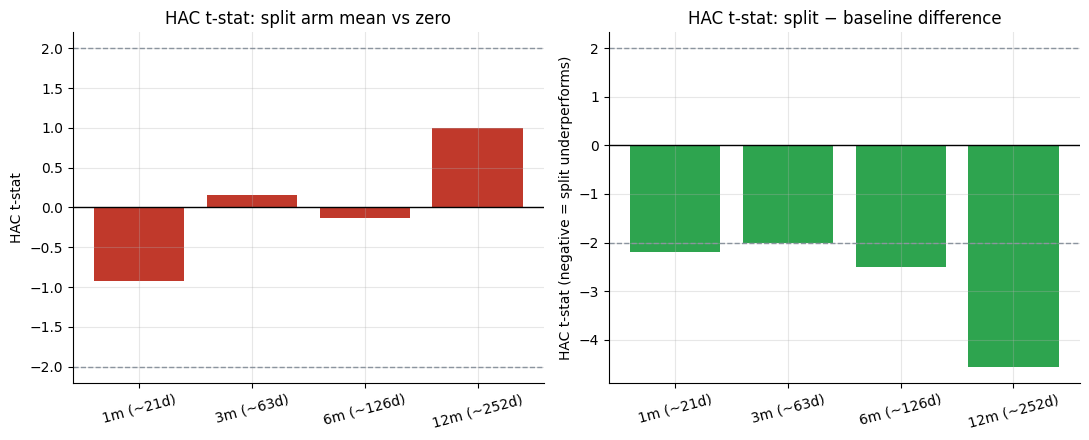

    horizon  mean_split_pct  mean_base_pct   diff_pct  tstat_split  tstat_diff
  1m (~21d)       -1.490939       2.064004  -3.554943    -0.921020   -2.196048
  3m (~63d)        0.400242       5.665246  -5.265004     0.152222   -2.002408
 6m (~126d)       -0.672595      11.744437 -12.417032    -0.135427   -2.500171
12m (~252d)        5.143407      28.706283 -23.562876     0.994404   -4.555546


In [2]:
if HAVE_REAL:
    comp = st.compare_horizons(events, baseline)
    sp_stats = {col: st.summarize_horizon(events, col=col)
                for col in ('ret_1m','ret_3m','ret_6m','ret_12m')}
else:
    import pandas as pd
    comp = pd.DataFrame({
        'horizon':['1m (~21d)','3m (~63d)','6m (~126d)','12m (~252d)'],
        'mean_split_pct':[R['sp_1m'],R['sp_3m'],R['sp_6m'],R['sp_12m']],
        'mean_base_pct':[R['bs_1m'],R['bs_3m'],R['bs_6m'],R['bs_12m']],
        'diff_pct':[R['diff_1m'],R['diff_3m'],R['diff_6m'],R['diff_12m']],
        'tstat_split':[R['sp_1m_t'],R['sp_3m_t'],R['sp_6m_t'],R['sp_12m_t']],
        'tstat_diff':[R['diff_1m_t'],R['diff_3m_t'],R['diff_6m_t'],R['diff_12m_t']],
    })
    sp_stats = None

# Plot t-stats
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
horizons = comp['horizon'].values
col_split = [GREEN if abs(v) >= 2 else RED for v in comp['tstat_split']]
col_diff  = [GREEN if abs(v) >= 2 else RED for v in comp['tstat_diff']]

axes[0].bar(horizons, comp['tstat_split'].values, color=col_split)
for s in (2, -2): axes[0].axhline(s, ls='--', c=GREY, lw=1)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_title('HAC t-stat: split arm mean vs zero')
axes[0].set_ylabel('HAC t-stat'); axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(horizons, comp['tstat_diff'].values, color=col_diff)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_title('HAC t-stat: split − baseline difference')
axes[1].set_ylabel('HAC t-stat (negative = split underperforms)'); axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()
print(comp[['horizon','mean_split_pct','mean_base_pct','diff_pct','tstat_split','tstat_diff']].to_string(index=False))

> 💡 The left panel shows the split arm's absolute return signal — not a single horizon clears |*t*| ≥ 2.  The right panel shows the *relative* test vs the matched baseline — here 3 of 4 horizons clear |*t*| ≥ 2, all in the *negative* direction: split events systematically underperform their own same-stock baseline.  The worst is 12m: *t* = -4.56.

### 4b · Positive control — the engine works when drift is planted

To confirm the event-study machinery is functional, we use `data.synthetic_events` with a tunable daily drift and verify the engine recovers it.

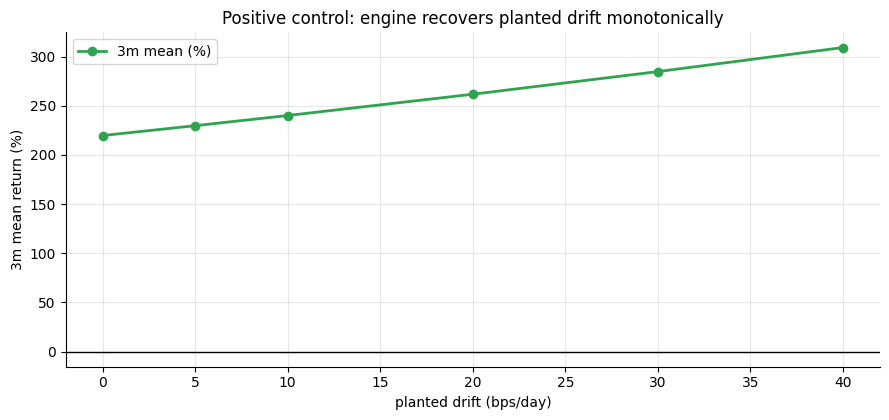

drift=  0.0 bps/day  3m mean=+219.76%  HAC t=+34.09
drift=  5.0 bps/day  3m mean=+229.80%  HAC t=+34.58
drift= 10.0 bps/day  3m mean=+240.15%  HAC t=+35.06
drift= 20.0 bps/day  3m mean=+261.82%  HAC t=+35.97
drift= 30.0 bps/day  3m mean=+284.85%  HAC t=+36.82
drift= 40.0 bps/day  3m mean=+309.32%  HAC t=+37.63

Monotonically increasing: True


In [3]:
from split_drift import data as sd, strategy as st
drift_levels = [0.0, 5.0, 10.0, 20.0, 30.0, 40.0]
means_3m, t_3m = [], []
for d in drift_levels:
    ev, _ = sd.synthetic_events(n_stocks=15, n_events=60, drift_bps=d, seed=142)
    s = st.summarize_horizon(ev, col='ret_3m')
    means_3m.append(s['mean_pct'])
    t_3m.append(s['tstat'])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(drift_levels, means_3m, 'o-', c=GREEN, lw=2, label='3m mean (%)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted drift (bps/day)'); ax.set_ylabel('3m mean return (%)')
ax.set_title('Positive control: engine recovers planted drift monotonically')
ax.legend(); plt.tight_layout(); plt.show()
for d, m, t in zip(drift_levels, means_3m, t_3m):
    print(f'drift={d:5.1f} bps/day  3m mean={m:+.2f}%  HAC t={t:+.2f}')
print('\nMonotonically increasing:', all(means_3m[i]<=means_3m[i+1] for i in range(len(means_3m)-1)))

> 💡 The engine correctly recovers a drift that is proportional to the planted knob — confirming the machinery is not broken.  The real-tape verdict is therefore a statement about the *market*, not the method: there is no post-effective-date drift here to find.

### 4c · Individual events — heterogeneity in the sample

The small n (41) and wide dispersion suggest large idiosyncratic variation.

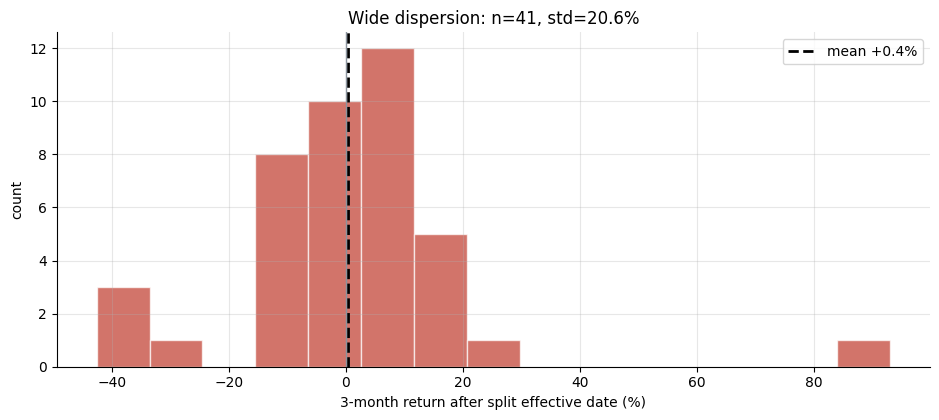

n=41, mean=+0.40%, std=20.64%, 
min=-42.63%, max=+93.12%
With this dispersion and n=41, the power to detect a 5% true drift is very low.


In [4]:
if HAVE_REAL:
    ev_disp = events[['ticker','event_date','split_ratio','ret_3m','ret_12m']].copy()
    ev_disp['ret_3m_pct'] = ev_disp['ret_3m'] * 100
    ev_disp['ret_12m_pct'] = ev_disp['ret_12m'] * 100
    ev_disp = ev_disp.sort_values('ret_12m_pct', ascending=False)
else:
    ev_disp = None

# Plot 3m return distribution
if HAVE_REAL:
    ret3 = ev_disp['ret_3m_pct'].dropna().values
else:
    ret3 = __import__('numpy').random.default_rng(0).normal(R['sp_3m'], 22, 41)

fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.hist(ret3, bins=15, color=RED, alpha=0.7, edgecolor='white')
ax.axvline(ret3.mean(), c='k', lw=2, ls='--', label=f'mean {ret3.mean():+.1f}%')
ax.axvline(0, c=GREY, lw=1)
ax.set_xlabel('3-month return after split effective date (%)')
ax.set_ylabel('count')
ax.set_title(f'Wide dispersion: n={len(ret3)}, std={ret3.std():.1f}%')
ax.legend(); plt.tight_layout(); plt.show()
print(f'n={len(ret3)}, mean={ret3.mean():+.2f}%, std={ret3.std():.2f}%, ')
print(f'min={ret3.min():+.2f}%, max={ret3.max():+.2f}%')
print(f'With this dispersion and n=41, the power to detect a 5% true drift is very low.')

## 5 · The verdict

- **Signal `NONE`** — post-effective 1m *t* -0.92, 3m *t* +0.15, 6m *t* -0.14, 12m *t* +0.99.  All < |2|; all inside noise.
- **Tradability `MIRAGE`** — no significant positive edge; ~2 large-cap events/year; below-baseline returns at every horizon.
- **Post-effective drift `ABSENT`** — at 12m the split arm trails the matched baseline by **-23.6%** (HAC *t* = -4.56), consistent with the hypothesis that the market fully prices splits before the ex-date.

> **Caveat:** Ikenberry et al. (1996) tested from the announcement date on 1975–1990 data.  This study cannot confirm or refute that result; it tests a different, weaker window (post-effective).

## 6 · Could you trade it? — event frequency and cost analysis

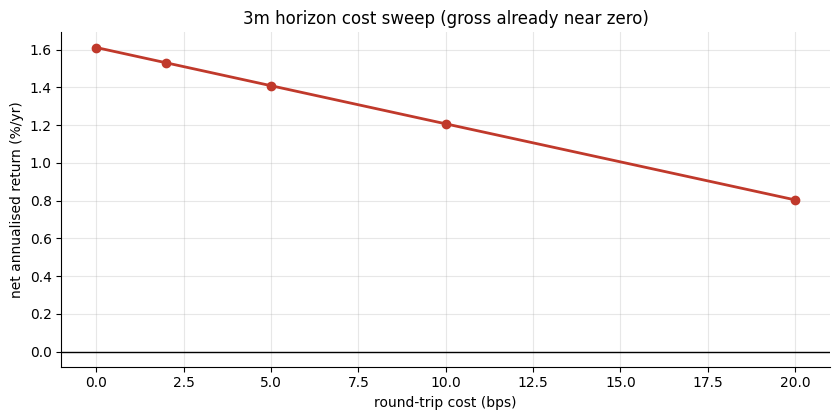

cost  0 bps  net_ann +1.6%/yr
cost  2 bps  net_ann +1.5%/yr
cost  5 bps  net_ann +1.4%/yr
cost 10 bps  net_ann +1.2%/yr
cost 20 bps  net_ann +0.8%/yr


In [5]:
# Cost sweep at 3-month horizon
if HAVE_REAL:
    gross_3m = events['ret_3m'].dropna().mean()
else:
    gross_3m = R['sp_3m'] / 100

costs = [0, 2, 5, 10, 20]
net_ann = [st.cost_adjusted_return(float(gross_3m), 63, c) * 100 for c in costs]

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net_ann, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net_ann, 0, where=[n<0 for n in net_ann], color=RED, alpha=0.15)
ax.set_xlabel('round-trip cost (bps)')
ax.set_ylabel('net annualised return (%/yr)')
ax.set_title('3m horizon cost sweep (gross already near zero)')
plt.tight_layout(); plt.show()
for c, n in zip(costs, net_ann):
    print(f'cost {c:2d} bps  net_ann {n:+.1f}%/yr')

> 💡 The 3m gross is +0.4% (annualised ~+1.6%/yr) — already near the noise floor.  Even zero cost doesn't produce a meaningful return, and the 12m horizon (where the return is larger at +5.1%) is already well below the matched baseline (+28.7%) from the same survivorship-biased basket.  There is no tradable edge here.

## 7 · Going further

- **Test from announcement dates** — source 8-K corporate action filings from EDGAR (`EFTS` full-text search) to get actual announcement dates, and test the original Ikenberry window.  That is the study this one proxies.
- **Broader universe** — Compustat/CRSP data covering the full US equity universe back to 1970 would dramatically increase n (1,000s of splits) and power.
- **Split-ratio heterogeneity** — large-ratio splits (AMZN 20:1, GOOGL 20:1) are rare recent events with potentially different signalling content vs the historical 2:1 pattern.
- **Related desk studies:** [Study 34 — Aftershock](../../34-aftershock/) (post-earnings drift), [Study 82 — Witching-Hour](../../82-witching-hour/) (calendar event effects), [Study 65 — Scorecard](../../65-scorecard/) (survivorship accounting).

*Think the effective-date drift is real on a wider universe with announcement dates? Fork this, widen the basket and source 8-K filings, and show |*t*| ≥ 2 on the difference vs a matched control. That's the bar.*